First 5 rows:
        Country  Year      Status  Life expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
2  Afghanistan  2013  Developing             59.9            268.0   
3  Afghanistan  2012  Developing             59.5            272.0   
4  Afghanistan  2011  Developing             59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624         65.0     1154  ...   
1             64     0.01               73.523582         62.0      492  ...   
2             66     0.01               73.219243         64.0      430  ...   
3             69     0.01               78.184215         67.0     2787  ...   
4             71     0.01                7.097109         68.0     3013  ...   

   Polio  Total expenditure  Diphtheria  HIV/AIDS         GDP  Population  \
0    6

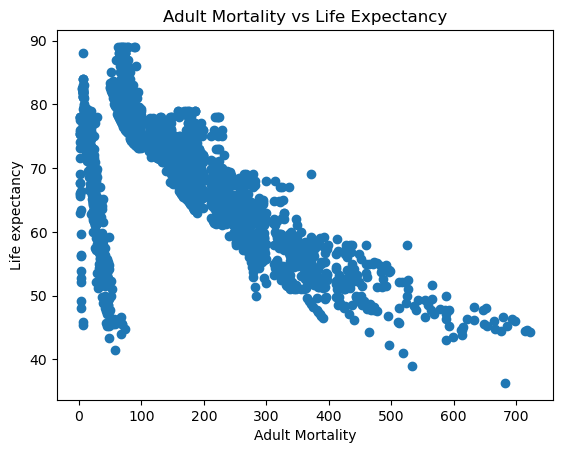

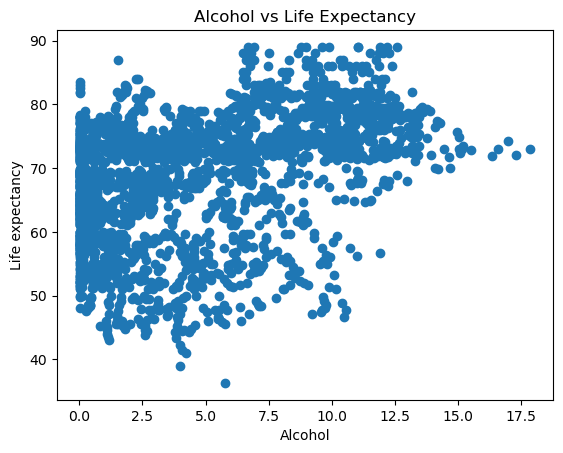

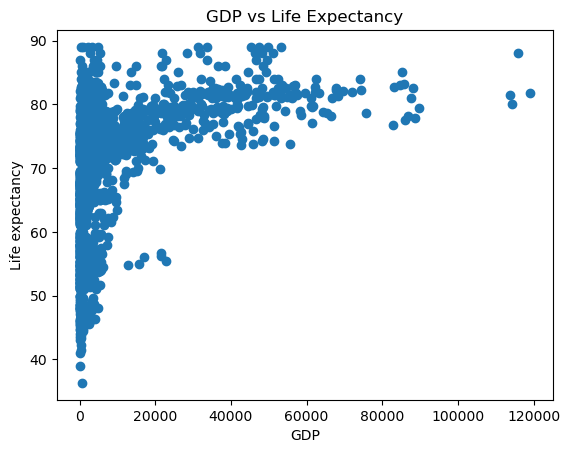

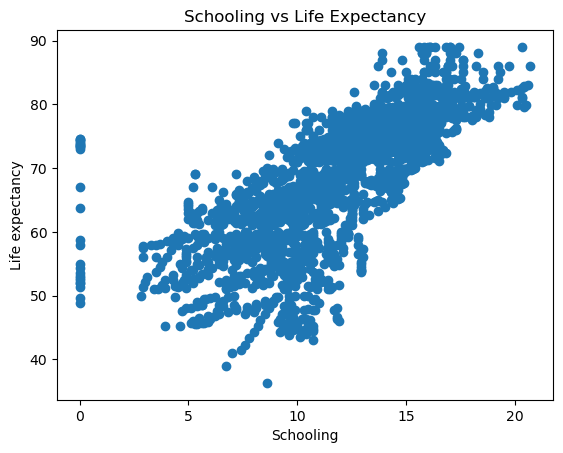

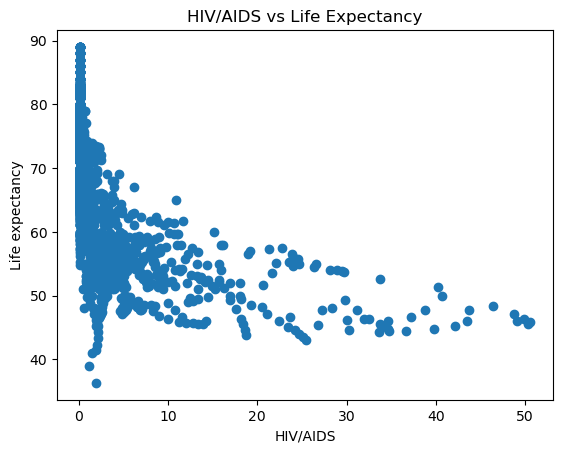

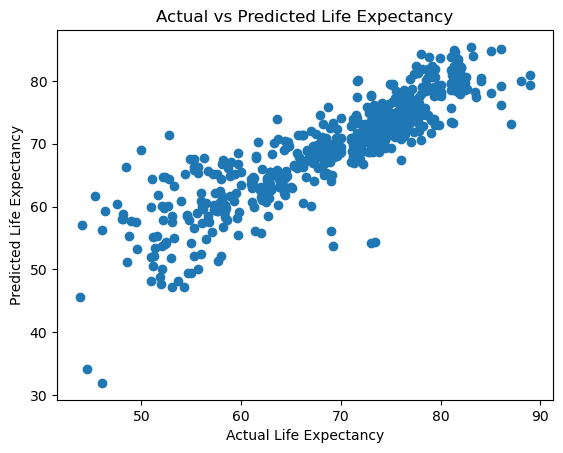

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 🔹 2. Load Dataset (UPDATE PATH if needed)
df = pd.read_csv("Life Expectancy Data.csv")

# 🔹 3. Fix Column Names (IMPORTANT)
df.columns = df.columns.str.strip()

print("First 5 rows:\n", df.head())

# 🔹 4. Data Exploration
print("\nMissing Values:\n", df.isnull().sum())
print("\nSummary:\n", df.describe())

# 🔹 5. Select Features and Target
features = ['Adult Mortality', 'Alcohol', 'GDP', 'Schooling', 'HIV/AIDS']
target = 'Life expectancy'

X = df[features]
y = df[target]

# 🔹 6. Handle Missing Values
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# 🔹 7. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 8. Build Model
model = LinearRegression()
model.fit(X_train, y_train)

# 🔹 9. Predictions
y_pred = model.predict(X_test)

# 🔹 10. Evaluation
print("\nModel Performance:")
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

# 🔹 11. Coefficients (Feature Importance)
print("\nFeature Importance:")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef}")

# 🔹 12. Scatter Plots (Feature vs Target)
for col in features:
    plt.figure()
    plt.scatter(df[col], df[target])
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs Life Expectancy")
    plt.show()

# 🔹 13. Actual vs Predicted Plot
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.show()